# Model Evaluation

Evaluate fitted spike models: convergence diagnostics, sparsity analysis,
replicate parameter correlations, global epistasis plots, and mutation
parameter export.

**Outline**
1. Load fitted models and training data
2. Convergence diagnostics
3. Shift sparsity analysis
4. Replicate parameter correlations
5. Global epistasis plots
6. Export mutations DataFrame and intermediate CSVs

In [1]:
import warnings

warnings.filterwarnings("ignore")

import os
import pickle
import sys

sys.path.insert(0, "notebooks")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import multidms.plot
from multidms.model_collection import ModelCollection

from _common import load_config, combine_replicate_muts

In [2]:
config_path = "config/config.yaml"

In [3]:
# Parameters
config_path = "config/config.yaml"


In [4]:
config = load_config(config_path)
spike = config["spike"]
fit_config = spike["fitting"]
lasso_choice = spike["lasso_choice"]
condition_titles = spike["condition_titles"]
condition_colors = spike["condition_colors"]
experiment_conditions = spike["experiment_conditions"]

output_dir = "results"

## Load data

In [5]:
with open(os.path.join(output_dir, "fit_collection.pkl"), "rb") as f:
    fit_collection_df = pickle.load(f)

func_score_df = pd.read_csv(
    os.path.join(output_dir, "training_functional_scores.csv")
).fillna({"aa_substitutions": ""})

model_collection = ModelCollection(fit_collection_df)
print(f"Loaded {len(fit_collection_df)} fitted models")
print(f"Loaded {len(func_score_df):,} training variants")

Loaded 14 fitted models
Loaded 281,158 training variants


## Convergence diagnostics

In [6]:
# Build summary table with fitted alpha and beta0 parameters
summary_rows = []
for _, row in model_collection.fit_models.iterrows():
    jm = row.model._jax_model
    r = {
        "dataset": row.dataset_name,
        "fusionreg": row.fusionreg,
        "converged": row.converged,
        "fit_time": row.fit_time,
    }
    # Per-condition loss
    for cond in experiment_conditions:
        loss_col = f"{cond}_loss_training"
        if loss_col in model_collection.fit_models.columns:
            r[f"loss_{condition_titles.get(cond, cond)}"] = row[loss_col]
    # Fitted alpha and beta0 per condition
    for cond in experiment_conditions:
        title = condition_titles.get(cond, cond)
        r[f"alpha_{title}"] = float(jm.α[cond])
        r[f"beta0_{title}"] = float(jm.φ[cond].β0)
    summary_rows.append(r)

summary_df = pd.DataFrame(summary_rows)
print(f"{summary_df['converged'].sum()}/{len(summary_df)} models converged\n")
summary_df.round(3)

8/14 models converged



,dataset,fusionreg,converged,fit_time,loss_Delta,loss_BA.1,loss_BA.2,alpha_Delta,beta0_Delta,alpha_BA.1,beta0_BA.1,alpha_BA.2,beta0_BA.2
0,rep_1,0.0,True,979,3145.643,9480.089,8271.396,5.926,0.026,6.157,0.210,5.881,0.039
1,rep_1,0.4,True,616,3354.925,9484.122,8565.297,6.099,-0.044,6.352,0.135,6.051,-0.025
2,rep_1,0.8,False,1566,3879.316,9460.927,9037.758,5.989,-0.003,5.792,0.342,6.469,-0.196
3,rep_1,1.6,True,627,5201.858,9484.436,10162.358,5.726,0.073,6.375,0.128,5.971,0.003
4,rep_1,3.2,True,1075,6328.016,9474.818,11640.125,2.176,2.240,6.094,0.229,5.053,0.366
5,rep_1,6.4,True,890,6596.412,9474.255,13239.243,2.078,2.628,6.073,0.237,4.370,0.684
6,rep_1,12.8,False,1064,6637.644,9454.326,14417.683,2.004,3.428,5.710,0.371,4.064,0.508
7,rep_2,0.0,False,1268,3597.770,7053.823,6735.751,5.941,0.009,5.851,0.358,5.299,0.344
8,rep_2,0.4,True,652,3878.584,7085.026,7071.741,6.113,-0.046,6.474,0.130,5.926,0.028
9,rep_2,0.8,True,599,4446.659,7086.564,7485.129,6.121,-0.042,6.515,0.115,5.964,0.012


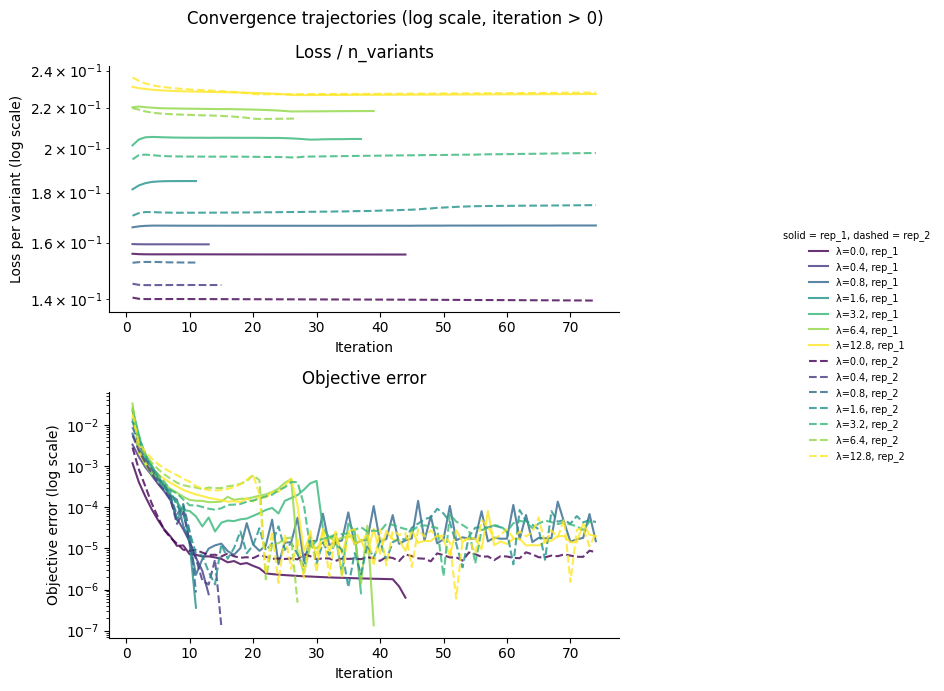

In [7]:
conv_data = model_collection.convergence_trajectory_df(
    id_vars=("dataset_name", "fusionreg")
)
conv_data.index.name = "step"
conv_data.reset_index(inplace=True)

# Normalize loss to per-variant scale
n_variants_map = {
    (row.dataset_name, row.fusionreg): len(row.model.data.variants_df)
    for _, row in fit_collection_df.iterrows()
}
conv_data["n_variants"] = conv_data.apply(
    lambda r: n_variants_map[(r["dataset_name"], r["fusionreg"])], axis=1
)
conv_data["loss_per_variant"] = conv_data["loss_trajectory"] / conv_data["n_variants"]

plot_df = conv_data.query("iteration > 0")

# Color by fusionreg, linestyle by replicate
fusionreg_values = sorted(plot_df["fusionreg"].unique())
cmap = plt.cm.viridis
colors = {fr: cmap(i / max(len(fusionreg_values) - 1, 1)) for i, fr in enumerate(fusionreg_values)}
linestyles = {"rep_1": "-", "rep_2": "--"}

fig, axes = plt.subplots(2, 1, figsize=(8, 7))

for (ds, fr), grp in plot_df.groupby(["dataset_name", "fusionreg"]):
    axes[0].semilogy(
        grp["iteration"], grp["loss_per_variant"],
        color=colors[fr], linestyle=linestyles.get(ds, "-"),
        label=f"\u03bb={fr}, {ds}", alpha=0.8,
    )
    axes[1].semilogy(
        grp["iteration"], grp["objective_error_trajectory"],
        color=colors[fr], linestyle=linestyles.get(ds, "-"),
        alpha=0.8,
    )

axes[0].set_title("Loss / n_variants")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss per variant (log scale)")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].set_title("Objective error")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective error (log scale)")
axes[1].spines[["top", "right"]].set_visible(False)

# Legend outside the plot area
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="center right", bbox_to_anchor=(1.18, 0.5),
    frameon=False, fontsize=7, title="solid = rep_1, dashed = rep_2",
    title_fontsize=7,
)

fig.suptitle("Convergence trajectories (log scale, iteration > 0)")
plt.tight_layout()
fig.subplots_adjust(right=0.78)
plt.show()

## Shift sparsity

Fraction of shift parameters that are exactly zero, across the
regularization grid. Uses the `ModelCollection.shift_sparsity` method
which returns an interactive Altair chart faceted by dataset and
shift parameter.

In [8]:
sparsity_chart, sparsity_data = model_collection.shift_sparsity(return_data=True)
sparsity_chart

cache miss - this could take a moment


alt.FacetChart(...)

## Replicate parameter correlations

Correlation of mutation parameters (beta, shift) between replicates
across the regularization grid. Uses the `ModelCollection.mut_param_dataset_correlation`
method which returns an interactive Altair chart.

In [9]:
corr_chart, corr_data = model_collection.mut_param_dataset_correlation(
    return_data=True
)
corr_chart

alt.FacetChart(...)

## Global epistasis plots

Global epistasis (GE) landscape at the chosen lasso strength, showing
the fitted sigmoid mapping from latent to observed phenotype.

rep_1 (fusionreg=3.2):


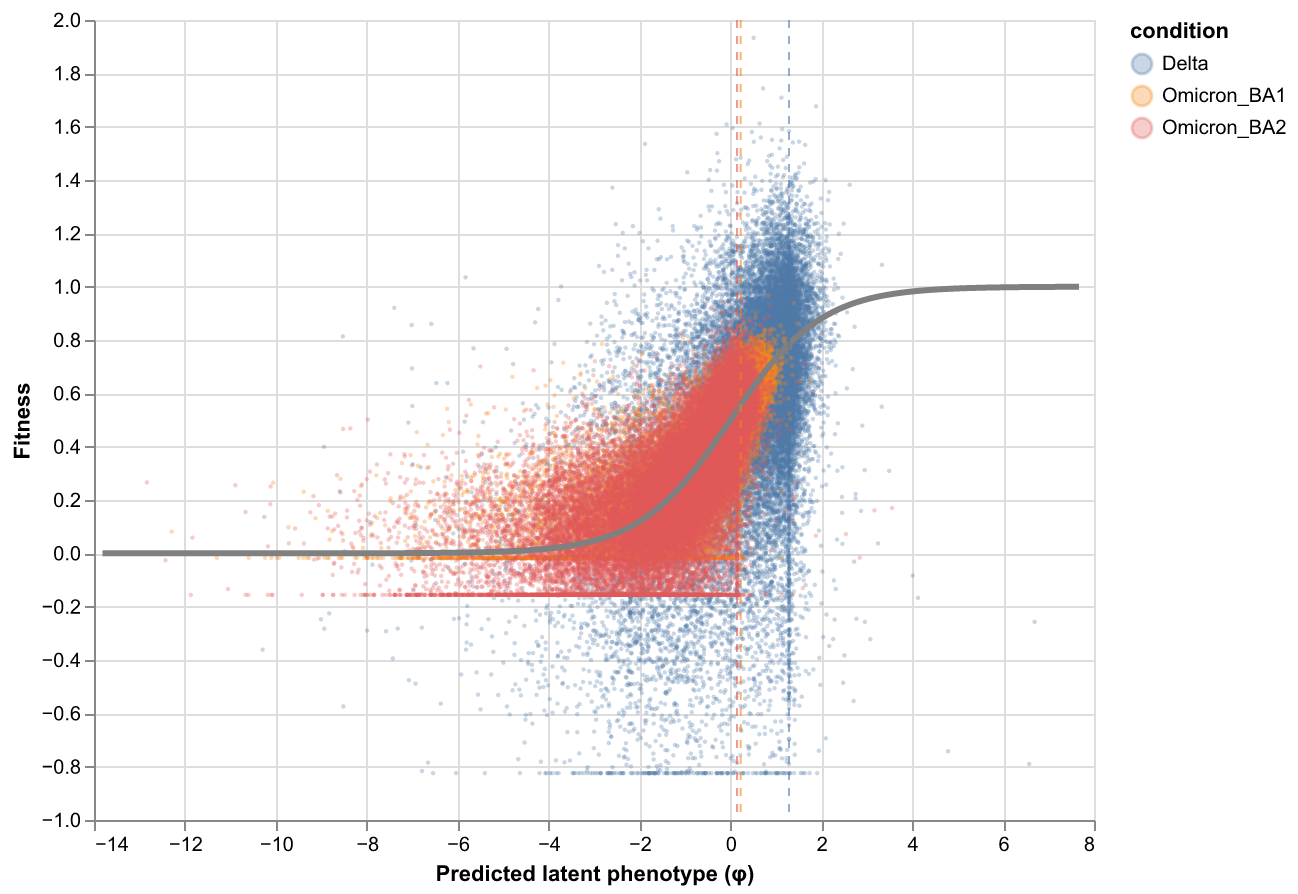

rep_2 (fusionreg=3.2):


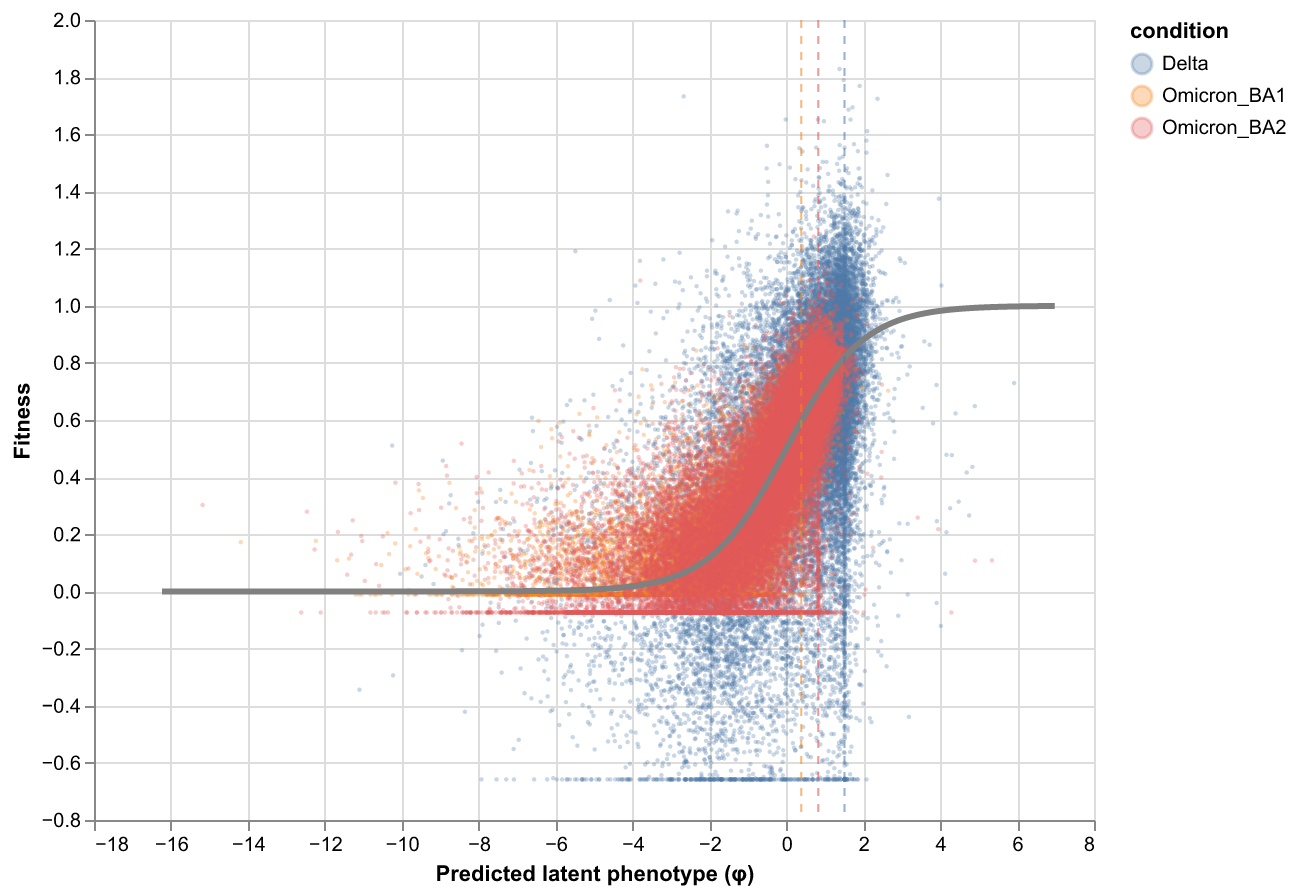

In [10]:
from IPython.display import display, Image
import tempfile

for ds_name in fit_collection_df["dataset_name"].unique():
    representative = (
        model_collection.fit_models
        .query(f"fusionreg == {lasso_choice} and dataset_name == '{ds_name}'")
    )
    if len(representative) == 0:
        print(f"No model at lasso={lasso_choice} for {ds_name}")
        continue
    model = representative.iloc[0].model
    print(f"{ds_name} (fusionreg={lasso_choice}):")
    chart = multidms.plot.ge_landscape(model)
    with tempfile.NamedTemporaryFile(suffix=".png") as tmp:
        chart.save(tmp.name, format="png", scale_factor=2)
        display(Image(filename=tmp.name))

## Export mutations DataFrame

Merge mutation parameters from both replicates at the chosen lasso strength.

In [11]:
fit_dict = {}
for _, row in model_collection.fit_models.query(
    f"fusionreg == {lasso_choice}"
).iterrows():
    fit_dict[row.dataset_name] = row.model

mutations_df = combine_replicate_muts(fit_dict)

mutations_df["sense"] = np.where(
    mutations_df["muts"].str.contains("*", regex=False),
    "stop",
    "nonsynonymous",
)

print(f"mutations_df: {len(mutations_df):,} mutations")
print(f"  nonsynonymous: {(mutations_df['sense'] == 'nonsynonymous').sum():,}")
print(f"  stop: {(mutations_df['sense'] == 'stop').sum():,}")
mutations_df.head()

mutations_df: 9,398 mutations
  nonsynonymous: 9,188
  stop: 210


,mutation,wts,sites,muts,rep_1_beta_Delta,rep_2_beta_Delta,avg_beta_Delta,rep_1_beta_Omicron_BA1,rep_2_beta_Omicron_BA1,avg_beta_Omicron_BA1,rep_1_beta_Omicron_BA2,rep_2_beta_Omicron_BA2,avg_beta_Omicron_BA2,rep_1_shift_Delta,rep_2_shift_Delta,avg_shift_Delta,rep_1_shift_Omicron_BA2,rep_2_shift_Omicron_BA2,avg_shift_Omicron_BA2,sense
0,M1F,M,1,F,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,nonsynonymous
1,M1I,M,1,I,-2.578499,-2.037218,-2.307858,-2.578499,-2.037218,-2.307858,-2.578499,-2.454212,-2.516355,0.0,0.0,0.0,0.0,-0.416995,-0.208497,nonsynonymous
2,M1K,M,1,K,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,nonsynonymous
3,M1L,M,1,L,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,nonsynonymous
4,M1T,M,1,T,-2.008708,-2.170207,-2.089458,-2.008708,-2.170207,-2.089458,-2.008708,-2.170207,-2.089458,0.0,0.0,0.0,0.0,0.000000,0.000000,nonsynonymous


## Save outputs

In [12]:
groupby = ("dataset_name", "fusionreg")
collection_muts_df = model_collection.split_apply_combine_muts(
    groupby=groupby
)

mutations_df.to_csv(os.path.join(output_dir, "mutations_df.csv"), index=False)
print(f"Saved mutations_df.csv ({len(mutations_df):,} rows)")

collection_muts_df.to_csv(os.path.join(output_dir, "collection_muts.csv"), index=False)
print(f"Saved collection_muts.csv ({len(collection_muts_df):,} rows)")

sparsity_data.to_csv(os.path.join(output_dir, "fit_sparsity.csv"), index=False)
print(f"Saved fit_sparsity.csv ({len(sparsity_data)} rows)")

corr_data.to_csv(os.path.join(output_dir, "library_replicate_correlation.csv"), index=False)
print(f"Saved library_replicate_correlation.csv ({len(corr_data)} rows)")

Saved mutations_df.csv (9,398 rows)


Saved collection_muts.csv (131,572 rows)
Saved fit_sparsity.csv (56 rows)
Saved library_replicate_correlation.csv (56 rows)
